# リハビリ離脱率分析ポートフォリオ

## 理学療法士としての臨床経験をもとに、整形外科外来リハビリにおける離脱率に影響する要因をSQL・統計分析で明らかにする。

## ※本データは架空データです。実患者の個人情報は一切含まれていません。

## 1. セットアップ：CSV → SQLite変換

In [23]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np
import sys
!{sys.executable} -m pip install pandas matplotlib seaborn scipy scikit-learn ipython-sql

# 日本語フォント設定（Windowsの場合は'MS Gothic'、Macは'Hiragino Sans'）
plt.rcParams['font.family'] = 'Hiragino Maru Gothic Pro'  # Macの場合

sns.set_style('whitegrid')
%matplotlib inline


You should consider upgrading via the '/Users/matsuurayukiya/.pyenv/versions/3.10.5/bin/python3.10 -m pip install --upgrade pip' command.


In [24]:
# CSVを読み込んでSQLiteデータベースに変換
patients   = pd.read_csv('patients.csv')
clinical   = pd.read_csv('clinical_records.csv')
diseases   = pd.read_csv('master_diseases.csv')
therapists = pd.read_csv('master_therapists.csv')

conn = sqlite3.connect('rehab_portfolio.db')

patients.to_sql('patients', conn, if_exists='replace', index=False)
clinical.to_sql('clinical_records', conn, if_exists='replace', index=False)
diseases.to_sql('master_diseases', conn, if_exists='replace', index=False)
therapists.to_sql('master_therapists', conn, if_exists='replace', index=False)

print('SQLiteデータベース作成完了: rehab_portfolio.db')
print(f'  patients          : {len(patients)}行')
print(f'  clinical_records  : {len(clinical)}行')
print(f'  master_diseases   : {len(diseases)}行')
print(f'  master_therapists : {len(therapists)}行')

SQLiteデータベース作成完了: rehab_portfolio.db
  patients          : 1000行
  clinical_records  : 1000行
  master_diseases   : 13行
  master_therapists : 6行


In [25]:
# ipython-sqlを使えるようにする（pip install ipython-sql が必要）
%load_ext sql
%sql sqlite:///rehab_portfolio.db
%config SqlMagic.style = '_DEPRECATED_DEFAULT'

The sql extension is already loaded. To reload it, use:
  %reload_ext sql


## 2. SQL分析：基本集計

### 2-1. 全体の離脱率


In [26]:
%%sql
SELECT
    COUNT(*) AS 総患者数,
    SUM(離脱フラグ) AS 離脱数,
    ROUND(AVG(離脱フラグ) * 100, 1) AS 離脱率
FROM clinical_records;

 * sqlite:///rehab_portfolio.db
Done.


総患者数,離脱数,離脱率
1000,250,25.0


## 2-2. 疾患別の離脱率（4テーブルJOIN）

In [27]:
%%sql
SELECT
    d.疾患名,
    COUNT(*) AS 患者数,
    ROUND(AVG(p.年齢), 1) AS 平均年齢,
    ROUND(AVG(c.離脱フラグ) * 100, 1) AS 離脱率
FROM patients p
JOIN master_diseases d   ON p.疾患ID = d.疾患ID
JOIN clinical_records c  ON p.患者ID = c.患者ID
GROUP BY d.疾患名
ORDER BY 離脱率 DESC;

 * sqlite:///rehab_portfolio.db
Done.


疾患名,患者数,平均年齢,離脱率
筋筋膜性腰痛症,140,70.3,56.4
梨状筋症候群,86,66.8,50.0
腰部脊柱管狭窄症,114,70.2,27.2
変形性股関節症,65,67.6,24.6
足関節捻挫,34,26.0,20.6
膝前十字靭帯損傷,37,27.1,18.9
変形性膝関節症,124,69.3,17.7
上腕骨骨折,48,72.7,14.6
腱板断裂,31,61.5,12.9
肩関節周囲炎,99,61.4,12.1


## 2-3. 保険種別 × 離脱率

In [28]:
%%sql
SELECT
    p.保険種別,
    COUNT(*) AS 患者数,
    ROUND(AVG(p.年齢), 1) AS 平均年齢,
    ROUND(AVG(c.離脱フラグ) * 100, 1) AS 離脱率
FROM patients p
JOIN clinical_records c ON p.患者ID = c.患者ID
GROUP BY p.保険種別
ORDER BY 離脱率 DESC;

 * sqlite:///rehab_portfolio.db
Done.


保険種別,患者数,平均年齢,離脱率
後期高齢者,164,79.0,29.9
国保,330,66.7,27.3
社会保険,428,58.4,24.1
労災,24,53.5,20.8
自賠責,54,48.2,5.6


## 2-4. 距離区分別 離脱率（CASE WHEN）

In [29]:
%%sql
SELECT
    CASE
        WHEN 自宅からの距離_km < 2  THEN '①2km未満'
        WHEN 自宅からの距離_km < 5  THEN '②2-5km'
        WHEN 自宅からの距離_km < 10 THEN '③5-10km'
        ELSE '④10km以上'
    END AS 距離区分,
    COUNT(*) AS 患者数,
    ROUND(AVG(離脱フラグ) * 100, 1) AS 離脱率
FROM clinical_records
GROUP BY 距離区分
ORDER BY 距離区分;

 * sqlite:///rehab_portfolio.db
Done.


距離区分,患者数,離脱率
①2km未満,348,21.6
②2-5km,307,25.7
③5-10km,233,25.8
④10km以上,112,32.1


## 2-5. 就労状況 × 疾患（梨状筋・筋筋膜性に絞る／サブクエリ）

In [30]:
%%sql
SELECT
    d.疾患名,
    p.就労状況,
    COUNT(*) AS 患者数,
    ROUND(AVG(c.離脱フラグ) * 100, 1) AS 離脱率
FROM patients p
JOIN master_diseases d  ON p.疾患ID = d.疾患ID
JOIN clinical_records c ON p.患者ID = c.患者ID
WHERE d.疾患名 IN ('梨状筋症候群', '筋筋膜性腰痛症')
GROUP BY d.疾患名, p.就労状況
ORDER BY d.疾患名, 離脱率 DESC;


 * sqlite:///rehab_portfolio.db
Done.


疾患名,就労状況,患者数,離脱率
梨状筋症候群,就労中,39,61.5
梨状筋症候群,無職,40,42.5
梨状筋症候群,主婦・主夫,5,40.0
梨状筋症候群,学生,2,0.0
筋筋膜性腰痛症,主婦・主夫,15,66.7
筋筋膜性腰痛症,就労中,39,61.5
筋筋膜性腰痛症,無職,82,53.7
筋筋膜性腰痛症,学生,4,25.0


## 3. Python分析：可視化

In [ ]:
SQL結果をDataFrameとして取得し、グラフ化する

In [31]:
# 分析用に全テーブルを結合
query = '''
SELECT p.*, c.初回FIMスコア, c.初回疼痛VAS, c.自宅からの距離_km,
       c.週治療頻度, c.治療期間_週, c.離脱フラグ,
       d.疾患名, d.部位, t.氏名 AS 担当セラピスト, t.経験年数
FROM patients p
JOIN clinical_records c  ON p.患者ID = c.患者ID
JOIN master_diseases d   ON p.疾患ID = d.疾患ID
JOIN master_therapists t ON p.セラピストID = t.セラピストID
'''
df = pd.read_sql(query, conn)
df.head()

,患者ID,年齢,性別,疾患ID,セラピストID,独居フラグ,就労状況,介護度,併存疾患あり,保険種別,初回FIMスコア,初回疼痛VAS,自宅からの距離_km,週治療頻度,治療期間_週,離脱フラグ,疾患名,部位,担当セラピスト,経験年数
0,PT0001,79,女性,D04,TH04,0,無職,非該当,0,後期高齢者,123,9,9.9,2,20,0,肩関節周囲炎,肩関節,PT_田中,1
1,PT0002,65,女性,D13,TH06,0,就労中,非該当,0,社会保険,121,5,12.5,1,23,0,TKA術後,膝関節,PT_渡辺,5
2,PT0003,72,男性,D09,TH03,0,無職,非該当,1,国保,120,4,0.3,2,17,0,橈骨遠位端骨折,手関節,PT_佐藤,8
3,PT0004,70,女性,D06,TH05,0,主婦・主夫,要支援2,1,社会保険,120,5,3.1,1,17,0,腰部脊柱管狭窄症,腰部,PT_伊藤,17
4,PT0005,71,女性,D02,TH01,0,無職,非該当,1,国保,124,1,2.1,2,5,1,梨状筋症候群,股関節,PT_山田,12


## 3-1. 疾患別 離脱率（横棒グラフ）

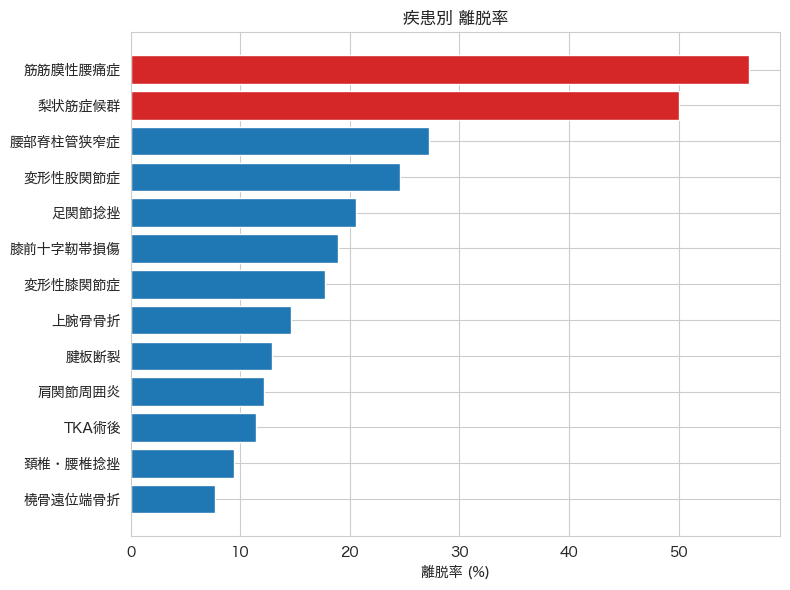

In [36]:
disease_dropout = df.groupby('疾患名')['離脱フラグ'].mean().sort_values() * 100

plt.figure(figsize=(8, 6))
colors = ['#d62728' if v >= 40 else '#1f77b4' for v in disease_dropout.values]
plt.barh(disease_dropout.index, disease_dropout.values, color=colors)
plt.xlabel('離脱率 (%)')
plt.title('疾患別 離脱率')
plt.tight_layout()
plt.show()

In [33]:
import matplotlib.font_manager as fm
fonts = [f.name for f in fm.fontManager.ttflist if 'Hiragino' in f.name or 'Gothic' in f.name]
print(fonts)

['Hiragino Sans', 'Hiragino Maru Gothic Pro', 'Hiragino Sans', 'YuGothic', 'Hiragino Sans', 'Hiragino Sans', 'Hiragino Sans', 'Hiragino Sans', 'Tsukushi B Round Gothic', 'Noto Sans Gothic', 'Hiragino Mincho ProN', 'Hiragino Sans', 'Hiragino Sans', 'Nanum Gothic', 'Toppan Bunkyu Gothic', 'Hiragino Sans', 'Apple SD Gothic Neo', 'Hiragino Sans', 'Apple SD Gothic Neo', 'Hiragino Sans', 'Hiragino Sans', 'YuGothic', 'Apple LiGothic', 'Noto Sans Gothic', 'BIZ UDGothic', 'Toppan Bunkyu Midashi Gothic', 'Hiragino Sans GB', 'Hiragino Sans', 'Hiragino Mincho ProN', 'Hiragino Sans', 'Tsukushi A Round Gothic', 'Hiragino Sans', 'Hiragino Sans', 'Hiragino Sans GB', 'AppleGothic', 'Hiragino Sans', 'Hiragino Maru Gothic Pro', 'Hiragino Sans', 'Hiragino Sans CNS', 'Hiragino Sans', 'Hiragino Sans', 'AppleGothic']


In [34]:
import matplotlib.font_manager as fm
for f in fm.fontManager.ttflist:
    if 'Hiragino' in f.name or 'Gothic' in f.name or 'Osaka' in f.name:
        print(f.name)
        

Hiragino Sans
Hiragino Maru Gothic Pro
Hiragino Sans
YuGothic
Hiragino Sans
Hiragino Sans
Hiragino Sans
Hiragino Sans
Tsukushi B Round Gothic
Noto Sans Gothic
Osaka
Hiragino Mincho ProN
Hiragino Sans
Hiragino Sans
Nanum Gothic
Toppan Bunkyu Gothic
Hiragino Sans
Apple SD Gothic Neo
Hiragino Sans
Apple SD Gothic Neo
Hiragino Sans
Hiragino Sans
YuGothic
Apple LiGothic
Noto Sans Gothic
BIZ UDGothic
Toppan Bunkyu Midashi Gothic
Hiragino Sans GB
Hiragino Sans
Hiragino Mincho ProN
Hiragino Sans
Tsukushi A Round Gothic
Hiragino Sans
Hiragino Sans
Hiragino Sans GB
AppleGothic
Hiragino Sans
Osaka
Hiragino Maru Gothic Pro
Hiragino Sans
Hiragino Sans CNS
Hiragino Sans
Hiragino Sans
AppleGothic


In [14]:
import matplotlib
import shutil
import os

cache_dir = matplotlib.get_cachedir()
shutil.rmtree(cache_dir, ignore_errors=True)
print(f"キャッシュを削除しました: {cache_dir}")
print("この後、Kernelを再起動してください")

キャッシュを削除しました: /Users/matsuurayukiya/.matplotlib
この後、Kernelを再起動してください


In [35]:
plt.rcParams['font.family'] = 'Hiragino Sans'
plt.rcParams['font.sans-serif'] = ['Hiragino Sans', 'Hiragino Maru Gothic Pro', 'Yu Gothic']

## 3-2. VASスコアと離脱率の関係（箱ひげ図）

/var/folders/sq/n5ck0rms7zz_qtqtw04gcymw0000gn/T/ipykernel_18992/3577807845.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='離脱フラグ', y='初回疼痛VAS', palette=['#1f77b4', '#d62728'])


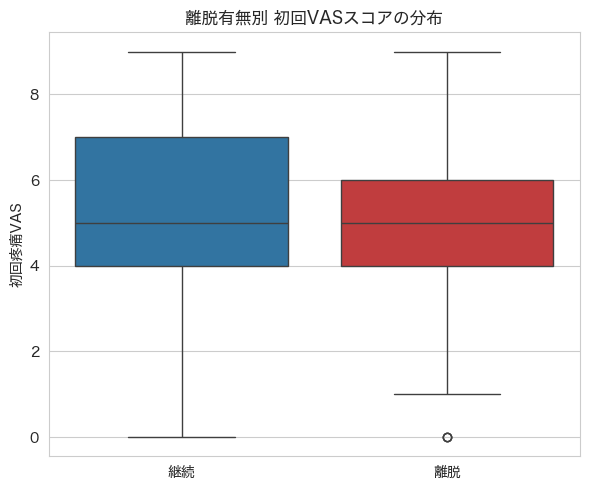

In [17]:
plt.figure(figsize=(6, 5))
sns.boxplot(data=df, x='離脱フラグ', y='初回疼痛VAS', palette=['#1f77b4', '#d62728'])
plt.xticks([0, 1], ['継続', '離脱'])
plt.xlabel('')
plt.ylabel('初回疼痛VAS')
plt.title('離脱有無別 初回VASスコアの分布')
plt.tight_layout()
plt.show()

## 3-3. 距離と離脱率の関係

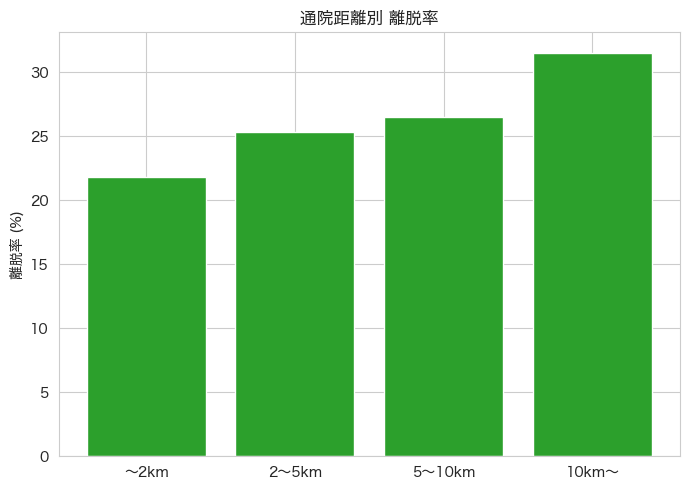

In [18]:
df['距離区分'] = pd.cut(df['自宅からの距離_km'], bins=[0,2,5,10,30],
                      labels=['〜2km','2〜5km','5〜10km','10km〜'])
dist_dropout = df.groupby('距離区分', observed=True)['離脱フラグ'].mean() * 100

plt.figure(figsize=(7, 5))
plt.bar(dist_dropout.index.astype(str), dist_dropout.values, color='#2ca02c')
plt.ylabel('離脱率 (%)')
plt.title('通院距離別 離脱率')
plt.tight_layout()
plt.show()

# 4. 統計検定

## 「見えた傾向が統計的に意味があるか」を検証する

## 4-1. カイ二乗検定：疾患名 × 離脱フラグ

In [19]:
cross_tab = pd.crosstab(df['疾患名'], df['離脱フラグ'])
chi2, p, dof, expected = stats.chi2_contingency(cross_tab)

print(f'カイ二乗統計量: {chi2:.2f}')
print(f'p値          : {p:.5f}')
print(f'判定         : {"有意差あり（疾患と離脱は関連あり）" if p < 0.05 else "有意差なし"}')

カイ二乗統計量: 148.47
p値          : 0.00000
判定         : 有意差あり（疾患と離脱は関連あり）


4-2. t検定：離脱群 vs 継続群の距離

In [20]:
group_continue = df[df['離脱フラグ']==0]['自宅からの距離_km']
group_dropout  = df[df['離脱フラグ']==1]['自宅からの距離_km']

t_stat, p_val = stats.ttest_ind(group_continue, group_dropout)

print(f'継続群 平均距離: {group_continue.mean():.2f} km')
print(f'離脱群 平均距離: {group_dropout.mean():.2f} km')
print(f't値   : {t_stat:.3f}')
print(f'p値   : {p_val:.5f}')
print(f'判定  : {"有意差あり" if p_val < 0.05 else "有意差なし"}')

継続群 平均距離: 4.42 km
離脱群 平均距離: 4.96 km
t値   : -1.611
p値   : 0.10759
判定  : 有意差なし


## 4-3. ロジスティック回帰：離脱に最も影響する要因は？

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 説明変数を準備（カテゴリ変数はダミー変数化）
features = df[['年齢','初回疼痛VAS','自宅からの距離_km','週治療頻度',
               '独居フラグ','併存疾患あり','初回FIMスコア']].copy()
features['就労中フラグ'] = (df['就労状況']=='就労中').astype(int)

X = features
y = df['離脱フラグ']

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

model = LogisticRegression()
model.fit(X_scaled, y)

# オッズ比で影響度を確認
odds_ratio = pd.DataFrame({
    '変数': X.columns,
    '係数': model.coef_[0],
    'オッズ比': np.exp(model.coef_[0])
}).sort_values('オッズ比', ascending=False)

odds_ratio

,変数,係数,オッズ比
0,年齢,0.253512,1.288543
5,併存疾患あり,0.165236,1.179671
2,自宅からの距離_km,0.112435,1.119000
6,初回FIMスコア,0.040686,1.041525
3,週治療頻度,0.034922,1.035539
4,独居フラグ,0.031106,1.031595
7,就労中フラグ,-0.004332,0.995677
1,初回疼痛VAS,-0.182428,0.833245


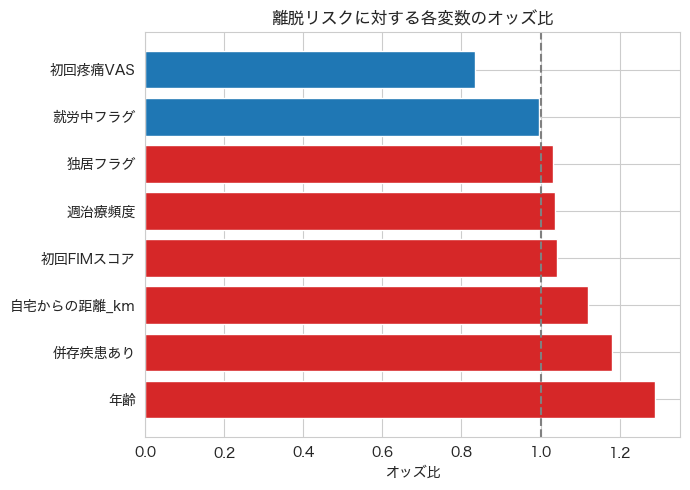

In [22]:
plt.figure(figsize=(7, 5))
colors = ['#d62728' if v > 1 else '#1f77b4' for v in odds_ratio['オッズ比']]
plt.barh(odds_ratio['変数'], odds_ratio['オッズ比'], color=colors)
plt.axvline(x=1, color='gray', linestyle='--')
plt.xlabel('オッズ比')
plt.title('離脱リスクに対する各変数のオッズ比')
plt.tight_layout()
plt.show()

# 5. 分析結果のまとめ・提言

## 主な発見

## 提言